In [25]:
from acceptor_TI import Problem

data_path = "../../acceptor_TI/data/"
file_name = "honeycomb.json"

problem = Problem(data_path=data_path, file_name=file_name)

In [26]:
location = "edge"
problem.setup(
    N_r = 30, # size of lattice in real space
    N_k = 200, # reciprocal space discretization
    location = location,
    BZ = "reduced"
)

Building Geometry...
Geometry - Done.
Building 'Edge' Hamiltonian...
'Edge' Hamiltonian - Done.


In [27]:
problem.model_options.solve_connectivity = True

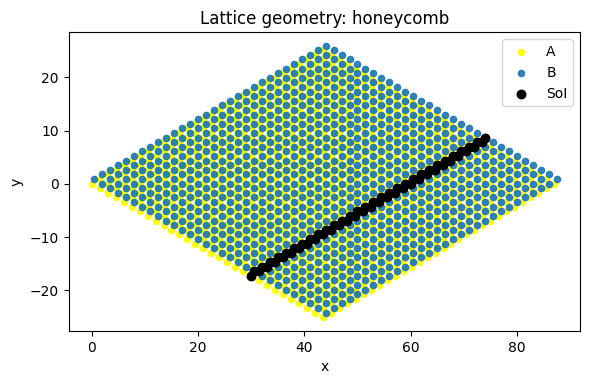

In [28]:
tb = problem.hamiltonian["edge"]["tight_binding"]
problem.geometry.plot_lattice(
    sites_of_interest=tb.sublattice_idxs
    )

In [29]:
problem.geometry.T

array([ 1.5      , -0.8660254])

In [30]:
problem.run(
    acceptor=False,
    H_type="reciprocal_space"
)

Calculating 'Edge' eigenvalues...
'Edge' Eigenvalues - Done.


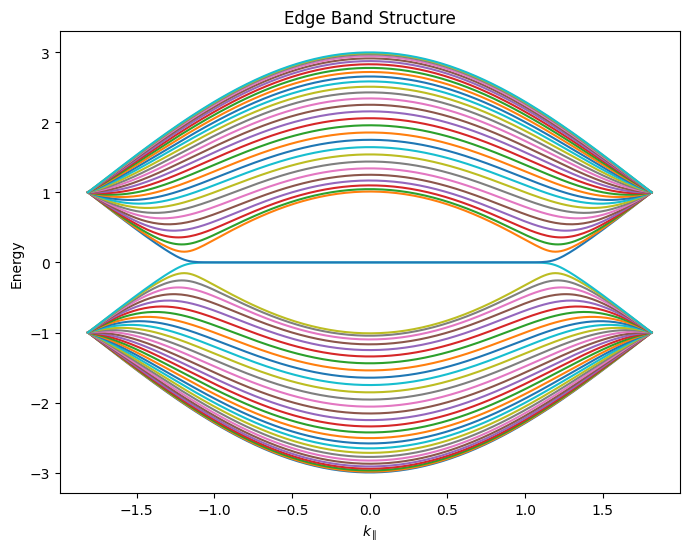

In [31]:
problem.plot(plot_type="dispersion", location=location)

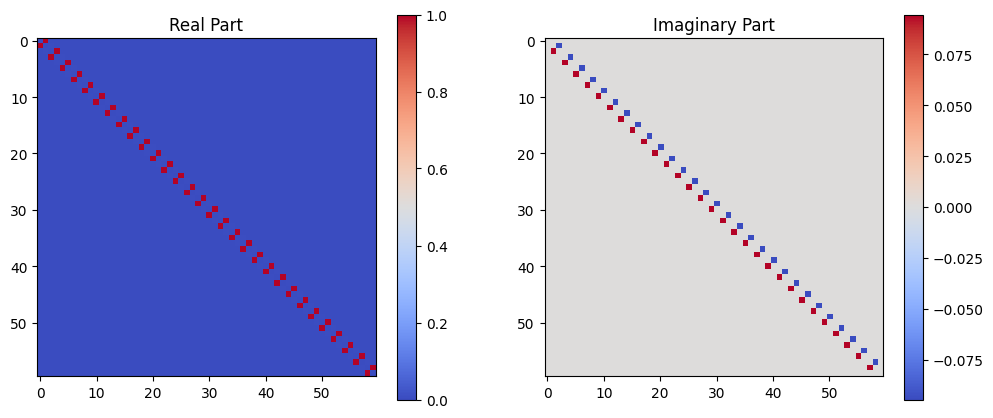

In [32]:
# TODO: edge band structure in literature (E=0 states explanation)
g = problem.geometry
k = g.k_edge[3]
H_k = tb._fourier_transform(g, k)
tb._visualise_matrix(H_k)